## 2 input XOR and XNOR gate

Can a linear model separate XOR?  NO!

| x1 | x2 | XOR | XNOR |
|---|---|---| ---|
| 0 | 0 | 0 | 1 |
| 0 | 1 | 1 | 0 |
| 1 | 0 | 1 | 0 |
| 1 | 1 | 0 | 1 |

<br></br>
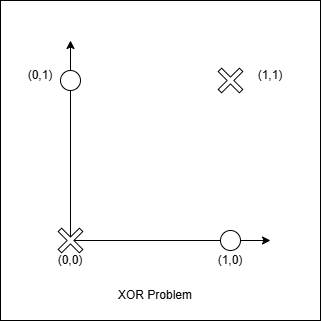


Hence, a motivation for us to study **Multi**- Layer perceptron.

## Dataset for training

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Input Data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# Target Output
Y = np.array([
    [0, 1],
    [1, 0],
    [1, 0],
    [0, 1]
], dtype=float)

## Different activation functions

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    # Assume a = sigmoid(z)
    return a * (1 - a)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(a):
    return 1 - a**2


## Different loss functions

In [3]:
def MSE_loss(y_pred, y_true):
  return np.mean((y_pred - y_true) ** 2) / 2

def BCE_loss(y_pred, y_true):
    epsilon = 1e-8  # for numerical stability
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))


## Network architecture

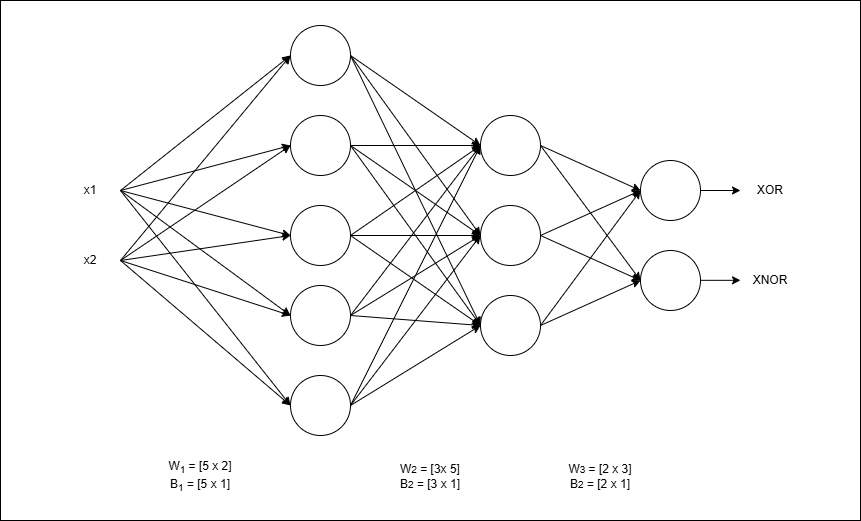

## Defining the Network

In [4]:
class XOR_NN_Scratch:
    def __init__(self, lr=0.5):
        self.lr = lr
        self.W1 = np.random.randn(5, 2)
        self.b1 = np.zeros((5, 1))
        self.W2 = np.random.randn(3, 5)
        self.b2 = np.zeros((3, 1))
        self.W3 = np.random.randn(2, 3)
        self.b3 = np.zeros((2, 1))

    def forward(self, X):
        self.Z1 = self.W1 @ X.T + self.b1
        self.A1 = tanh(self.Z1)
        self.Z2 = self.W2 @ self.A1 + self.b2
        self.A2 = tanh(self.Z2)
        self.Z3 = self.W3 @ self.A2 + self.b3
        self.A3 = sigmoid(self.Z3)
        return self.A3

    def backward(self, X, Y):
        m = X.shape[0]
        dA3 = self.A3 - Y.T
        dZ3 = dA3 * sigmoid_derivative(self.A3)
        dW3 = (1/m) * dZ3 @ self.A2.T
        db3 = (1/m) * np.sum(dZ3, axis=1, keepdims=True)
        dA2 = self.W3.T @ dZ3
        dZ2 = dA2 * tanh_derivative(self.A2)
        dW2 = (1/m) * dZ2 @ self.A1.T
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
        dA1 = self.W2.T @ dZ2
        dZ1 = dA1 * tanh_derivative(self.A1)
        dW1 = (1/m) * dZ1 @ X
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, Y, epochs=5000):
        losses = []
        for _ in range(epochs):
            y_hat = self.forward(X)
            loss = BCE_loss(y_hat, Y.T)
            losses.append(loss)
            self.backward(X, Y)
        return losses


## Training the Network

In [5]:
model = XOR_NN_Scratch(lr=0.5)
losses = model.train(X, Y, epochs=5000)

In [6]:
probs = model.forward(X).T
preds = (probs > 0.5).astype(int)

print("\nFinal predictions [XOR, XNOR]:")
print("\nInput → Output")
for x, p, pr in zip(X, preds, probs):
    print(f"{x.astype(int)} → {p} (prob={np.round(pr, 3)})")


Final predictions [XOR, XNOR]:

Input → Output
[0 0] → [0 1] (prob=[0.011 0.987])
[0 1] → [1 0] (prob=[0.992 0.005])
[1 0] → [1 0] (prob=[0.984 0.017])
[1 1] → [0 1] (prob=[0.009 0.986])


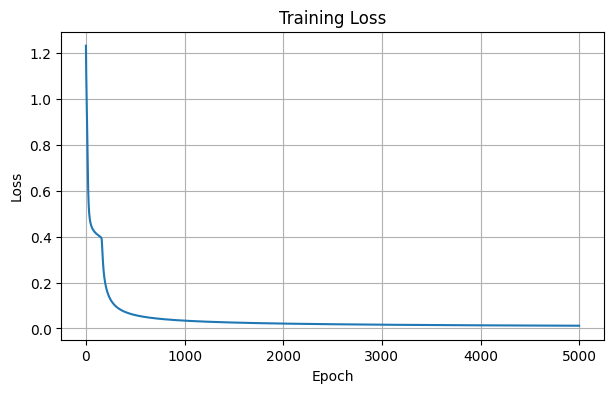

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## PyTorch Implementation

(No way we are going to write everything from scratch everytime!)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
Y = torch.tensor([[0., 1.], [1., 0.], [1., 0.], [0., 1.]])

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 5)
        self.fc2 = nn.Linear(5, 3)
        self.fc3 = nn.Linear(3, 2)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

model = XORNet()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.5)

losses = []
for epoch in range(5000):
    y_hat = model(X)
    loss = criterion(y_hat, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f'Final loss: {losses[-1]:.6f}')
probs = model(X).detach().numpy()
preds = (probs > 0.5).astype(int)
print('\nFinal predictions [XOR, XNOR]:')
for x, p, pr in zip(X.numpy(), preds, probs):
    print(f'{x.astype(int)} -> {p} (prob={pr.round(3)})')


Final loss: 0.000277

Final predictions [XOR, XNOR]:
[0 0] -> [0 1] (prob=[0. 1.])
[0 1] -> [1 0] (prob=[1. 0.])
[1 0] -> [1 0] (prob=[1. 0.])
[1 1] -> [0 1] (prob=[0. 1.])
